Environment: velocity

In [19]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy

In [3]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)

# Differential expression pseudobulk analysis with PyDEseq2

Article describing PyDESeq2: https://academic.oup.com/bioinformatics/article/39/9/btad547/7260507

Article describing DESeq2: https://link.springer.com/article/10.1186/s13059-014-0550-8

In [10]:
cells_mask = (raw_adata.obs["sample"] == sample).to_numpy()

In [11]:
raw_adata.X[cells_mask]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 8144522 stored elements and shape (1558, 48526)>

In [22]:
# Combine counts within samples

sample_names = adata.obs["sample"].unique()

pseudobulk_rows = []
pseudobulk_index = []
sample_metadata_list = []

adata_raw = adata.raw.to_adata()
filtered_adata = adata_raw[:, adata.var_names].copy()
filtered_adata.X = filtered_adata.X.toarray()

for sample in sample_names:
    cells_mask = filtered_adata.obs["sample"] == sample
    sample_X = filtered_adata.X[cells_mask]
    summed_counts = sample_X.sum(axis=0)
        
    pseudobulk_rows.append(summed_counts)
    pseudobulk_index.append(sample)
    
    # Determine the group of the sample
    group = adata.obs.loc[cells_mask, "group"].iloc[0]
    day = adata.obs.loc[cells_mask, "day"].iloc[0]
    sample_metadata_list.append({"sample": sample, "group": group, "day": day})

# Create the counts dataframe
counts_df = pandas.DataFrame(
    data=pseudobulk_rows,
    index=pseudobulk_index,
    columns=adata.var_names
)

# Create metadata dataframe
metadata_df = pandas.DataFrame(sample_metadata_list).set_index("sample")

In [23]:
# Differential expression analysis with pydeseq2

reprogramming_adata = adata[adata.obs["group"].isin({"Hic2", "control"})].copy()
inference = pydeseq2.dds.DefaultInference(n_cpus=8)
dds = pydeseq2.dds.DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="~group",
    refit_cooks=True,
    inference=inference
)

# Fit model
dds.deseq2()


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.26 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [24]:
single_cell_results = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "control"], inference=inference)

# compute p-values and adjusted p-values
single_cell_results.summary()

Log2 fold change & Wald test p-value: group Hic2 vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_names                                                                
Rb1cc1        2318.947239       -0.259296  0.238486 -1.087260  0.276922   
Fam150a         33.681927        0.332820  1.157078  0.287638  0.773624   
Cpa6            31.666928       -0.140193  0.817325 -0.171526  0.863810   
Prex2          240.640240        1.501007  0.518589  2.894407  0.003799   
Sulf1          738.370112        0.096582  0.585882  0.164849  0.869063   
...                   ...             ...       ...       ...       ...   
Gpm6b          570.665729       -1.986462  0.539814 -3.679898  0.000233   
Egfl6          163.893234        0.480876  0.779187  0.617151  0.537135   
Tmsb4x      114801.410420        0.667609  0.384953  1.734261  0.082872   
Erdr1         1488.446656        0.979016  0.536278  1.825574  0.067915   
AC168977.1       8.793828       -0.84497

Running Wald tests...
... done in 0.11 seconds.



In [25]:
# Whether genes of interest are up- or downregulated

stem_cell_tfs = ['Jarid2', 'Klf2', 'Rest', 'Tcf7l1', 'Zfp42']
dead_end_tfs = ['Dmrtc2', 'Myc', 'Ovol1', 'Tlx2', 'Zbtb7c', 'Cdh1']
genes_of_interest = stem_cell_tfs + dead_end_tfs + ["Hic2", "Klf4"]

In [26]:
single_cell_results.results_df.loc[dead_end_tfs + ["Hic2", "Klf4"], ["log2FoldChange", "padj"]].sort_values("log2FoldChange")

,log2FoldChange,padj
gene_names,,
Ovol1,-3.455977,0.000086
Dmrtc2,-3.345847,0.001318
Tlx2,-3.273428,0.000412
Cdh1,-2.046292,0.040079
Zbtb7c,-1.658549,0.008516
Myc,-0.921983,0.181602
Klf4,-0.297212,0.617311
Hic2,1.940136,0.000805


In [27]:
single_cell_results.results_df.loc[stem_cell_tfs].sort_values("padj")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Tcf7l1,1546.417777,1.046853,0.436012,2.400972,0.016352,0.106040
Rest,5317.869759,0.608820,0.375868,1.619771,0.105281,0.325349
Jarid2,5043.174798,0.672174,0.621501,1.081533,0.279460,0.557798
Zfp42,9402.529481,0.694871,0.683752,1.016262,0.309504,0.589281
Klf2,4946.698465,0.496954,0.595967,0.833862,0.404359,0.674867


In [28]:
# Most upregulated in control

single_cell_results.results_df.query("padj < 0.05 and log2FoldChange < 0").sort_values("log2FoldChange").head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
2310046K23Rik,36.630626,-8.076158,1.861510,-4.338499,1.434589e-05,4.985198e-04
Padi4,102.753997,-5.627815,0.840025,-6.699580,2.090193e-11,5.810736e-09
A530040E14Rik,29.078311,-5.143972,1.521819,-3.380147,7.244708e-04,1.076199e-02
Mal2,390.601943,-5.077882,0.862176,-5.889611,3.871046e-09,6.848233e-07
Vsig8,69.897847,-4.936132,0.870293,-5.671802,1.413029e-08,1.964110e-06
Prss32,1015.752608,-4.897022,0.978839,-5.002888,5.647781e-07,3.724973e-05
Krt14,1417.224585,-4.671076,0.668120,-6.991370,2.722149e-12,1.059460e-09
Ly6g6c,5673.391925,-4.639866,0.956201,-4.852397,1.219783e-06,6.688369e-05
Lgals7,9620.788784,-4.607609,0.848257,-5.431854,5.577160e-08,5.426577e-06


In [29]:
# Most upregulated in Hic2

single_cell_results.results_df.query("padj < 0.05 and log2FoldChange > 0").sort_values("log2FoldChange", ascending=False).head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Xist,897.755005,4.000480,0.997063,4.012265,6.013898e-05,1.560406e-03
Cd36,25.113393,3.898497,1.146597,3.400059,6.737121e-04,1.024253e-02
Cacna1e,14.837098,3.776567,1.196606,3.156065,1.599132e-03,2.033929e-02
Stra8,87.805244,3.629002,1.126099,3.222630,1.270195e-03,1.704689e-02
Spock1,12.674791,3.623405,1.049825,3.451438,5.576076e-04,8.821987e-03
Marc1,24.365851,3.581340,0.897606,3.989880,6.610664e-05,1.670695e-03
Xirp2,82.763095,3.126569,0.873456,3.579538,3.442023e-04,6.120382e-03
Cdh5,19.421838,2.996443,1.065191,2.813057,4.907296e-03,4.664864e-02
Myl3,33.709208,2.991289,0.839495,3.563199,3.663621e-04,6.365542e-03


# Differential expression in bulk data with PyDEseq2

Article describing PyDESeq2: https://academic.oup.com/bioinformatics/article/39/9/btad547/7260507

Article describing DESeq2: https://link.springer.com/article/10.1186/s13059-014-0550-8

In [30]:
bulk_counts = pandas.read_csv("RNA Sequencing Data/Bulk RNA sequencing data Hic2/counts2.tsv", sep="\t", index_col=0).T
samples = bulk_counts.index.to_list()
print(samples)

['Day2_BFP_Rep1', 'Day2_BFP_Rep2', 'Day2_BFP_Rep3', 'Day2_Hic2_Rep1', 'Day2_Hic2_Rep2', 'Day2_Hic2_Rep3', 'Day4_BFP_Rep1', 'Day4_BFP_Rep1-2', 'Day4_BFP_Rep2', 'Day4_BFP_Rep3', 'Day4_Hic2_Rep1', 'Day4_Hic2_Rep1-2', 'Day4_Hic2_Rep2', 'Day4_Hic2_Rep3', 'Day6_BFP_Rep1', 'Day6_BFP_Rep2', 'Day6_BFP_Rep3', 'Day6_Hic2_Rep1', 'Day6_Hic2_Rep2', 'Day6_Hic2_Rep3', 'Day10_BFP_Rep1', 'Day10_BFP_Rep2', 'Day10_BFP_Rep3', 'Day10_Hic2_Rep1', 'Day10_Hic2_Rep2', 'Day10_Hic2_Rep3', 'ESC_BFP_Rep1', 'ESC_BFP_Rep2', 'ESC_BFP_Rep3', 'ESC_Hic2-gRNA_Rep1', 'ESC_Hic2-gRNA_Rep2', 'ESC_Hic2-gRNA_Rep3', 'ESC_Zeo-gRNA_Rep1', 'ESC_Zeo-gRNA_Rep2', 'ESC_Zeo-gRNA_Rep3', 'iPSC_BFP_Rep1', 'iPSC_BFP_Rep2', 'iPSC_BFP_Rep3', 'iPSC_Hic2_Rep1', 'iPSC_Hic2_Rep2', 'iPSC_Hic2_Rep3', 'MEF_BFP_Rep1', 'MEF_BFP_Rep2', 'MEF_BFP_Rep3', 'MEF_Hic2_Rep1', 'MEF_Hic2_Rep2', 'MEF_Hic2_Rep3']


In [31]:
# Create metadata dataframe

sample_metadata_list = []

for sample in samples:
    sample_name_list = sample.split("_")
    if ("Day" in sample_name_list[0]):
        day = int(sample_name_list[0][3:])
        experiment = "reprogramming"
    else:
        day = 0
        experiment = sample_name_list[0]
    group = sample_name_list[1]
    replicate_list = sample_name_list[2][3:].split("-")
    replicate = replicate_list[0]
    if len(replicate_list) == 2:
        batch = int(replicate_list[1])
    else:
        batch = 1 if experiment in {"reprogramming", "MEF"} else 2
    
    sample_metadata_list.append({"sample": sample, "day": day, "experiment": experiment, "group": group, "replicate": replicate, "batch": batch})

# Create metadata dataframe
metadata_df = pandas.DataFrame(sample_metadata_list).set_index("sample")

metadata_df

,day,experiment,group,replicate,batch
sample,,,,,
Day2_BFP_Rep1,2,reprogramming,BFP,1,1
Day2_BFP_Rep2,2,reprogramming,BFP,2,1
Day2_BFP_Rep3,2,reprogramming,BFP,3,1
Day2_Hic2_Rep1,2,reprogramming,Hic2,1,1
Day2_Hic2_Rep2,2,reprogramming,Hic2,2,1
Day2_Hic2_Rep3,2,reprogramming,Hic2,3,1
Day4_BFP_Rep1,4,reprogramming,BFP,1,1
Day4_BFP_Rep1-2,4,reprogramming,BFP,1,2
Day4_BFP_Rep2,4,reprogramming,BFP,2,1


In [32]:
# Fix duplicated columns
duplicated_columns = bulk_counts.columns[bulk_counts.columns.duplicated()].to_list()
print(duplicated_columns)

# These likely result from Excel misinterpreting gene names as dates, possibly MARC1 and MARC2. They can be ignored.
bulk_counts = bulk_counts.drop(columns=duplicated_columns)

['Mar-01', 'Mar-02']


In [33]:
# Find columns that are also in the adata object

variable_genes = adata.var.index.to_numpy()
common_genes = numpy.intersect1d(variable_genes, bulk_counts.columns.to_numpy())

## Differential expression during the reprogramming experiment

In [34]:
reprogramming_samples = metadata_df.query("experiment == \"reprogramming\"").index.to_list()
print(metadata_df.loc[reprogramming_samples])

                  day     experiment group replicate  batch
sample                                                     
Day2_BFP_Rep1       2  reprogramming   BFP         1      1
Day2_BFP_Rep2       2  reprogramming   BFP         2      1
Day2_BFP_Rep3       2  reprogramming   BFP         3      1
Day2_Hic2_Rep1      2  reprogramming  Hic2         1      1
Day2_Hic2_Rep2      2  reprogramming  Hic2         2      1
Day2_Hic2_Rep3      2  reprogramming  Hic2         3      1
Day4_BFP_Rep1       4  reprogramming   BFP         1      1
Day4_BFP_Rep1-2     4  reprogramming   BFP         1      2
Day4_BFP_Rep2       4  reprogramming   BFP         2      1
Day4_BFP_Rep3       4  reprogramming   BFP         3      1
Day4_Hic2_Rep1      4  reprogramming  Hic2         1      1
Day4_Hic2_Rep1-2    4  reprogramming  Hic2         1      2
Day4_Hic2_Rep2      4  reprogramming  Hic2         2      1
Day4_Hic2_Rep3      4  reprogramming  Hic2         3      1
Day6_BFP_Rep1       6  reprogramming   B

In [35]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[reprogramming_samples],
    metadata=metadata_df.loc[reprogramming_samples],
    design="~C(day) + C(batch) + group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
reprogramming_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
reprogramming_de_stats.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 1.82 seconds.

Fitting dispersion trend curve...
... done in 0.95 seconds.

Fitting MAP dispersions...
... done in 1.79 seconds.

Fitting LFCs...
... done in 2.05 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3       18118.223009       -0.237734  0.046419 -5.121533  3.030622e-07   
Pbsn            0.000000             NaN       NaN       NaN           NaN   
Cdc45        1046.343936        0.800273  0.094942  8.429115  3.482879e-17   
H19          4548.672607        0.729453  0.114614  6.364406  1.960472e-10   
Scml2         183.121673       -0.602971  0.144454 -4.174135  2.991210e-05   
...                  ...             ...       ...       ...           ...   
BX571804.1      0.000000             NaN       NaN       NaN           NaN   
AC154773.1      0.000000             NaN       NaN       NaN           NaN   
AL662853.1      0.286036        0.360430  3.104910  0.116084  9.075861e-01   
AC145556.1      0.781459       -1.160610  1.788139 -0.649060  5.162996e-01   
CT868734.1      0.000000             NaN       NaN       NaN           NaN   

       

... done in 1.55 seconds.



In [36]:
# Dead end drivers

reprogramming_de_stats.results_df.loc[dead_end_tfs+["Hic2", "Klf4"], ["log2FoldChange", "padj"]].sort_values("log2FoldChange")

,log2FoldChange,padj
Ovol1,-1.451013,8.662382e-14
Tlx2,-1.107785,2.177436e-11
Zbtb7c,-0.943320,8.875440e-57
Dmrtc2,-0.917730,3.003524e-05
Cdh1,-0.650625,1.697320e-09
Myc,-0.137470,1.902087e-01
Klf4,-0.025929,8.159049e-01
Hic2,2.198816,2.517469e-92


In [37]:
# Stem cell drivers

reprogramming_de_stats.results_df.loc[stem_cell_tfs, ["log2FoldChange", "padj"]].sort_values("log2FoldChange")

,log2FoldChange,padj
Klf2,-0.180294,5.962362e-01
Rest,0.492894,6.120062e-05
Jarid2,0.820343,1.213284e-08
Tcf7l1,1.263931,2.178525e-13
Zfp42,1.344900,6.673669e-18


In [38]:
# Higher expression in control

reprogramming_de_stats.results_df.loc[common_genes].query("padj < 0.05 and log2FoldChange < 0").sort_values("log2FoldChange").head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
2310046K23Rik,121.261593,-5.026695,0.526483,-9.547682,1.326310e-21,4.142749e-20
Krt14,5110.427482,-4.106556,0.314381,-13.062360,5.402643e-39,5.300643e-37
Krt6a,8104.897532,-3.767656,0.231002,-16.310079,8.368502e-60,2.198591e-57
Mlc1,6.222436,-3.765394,0.772700,-4.873033,1.098978e-06,6.231496e-06
Slurp1,817.514135,-3.661155,0.243806,-15.016651,5.712186e-51,9.931224e-49
Sel1l3,35.552444,-3.592158,0.570257,-6.299193,2.991987e-10,2.772161e-09
Chit1,745.571491,-3.592043,0.181281,-19.814780,2.219770e-87,2.099458e-84
Mmp13,74.221433,-3.585201,0.291299,-12.307644,8.239388e-35,6.537595e-33
Krt17,5304.148465,-3.505668,0.151732,-23.104385,4.183093e-118,1.098991e-114
Fam180a,50.590588,-3.467625,0.341159,-10.164247,2.863245e-24,1.124608e-22


The high upregulation of 2310046K23Rik, also known as Small proline rich protein 5 (Sprr5) is very interesting.

Function of human Sprr5 according to Uniprot: "Positively regulates keratinocyte differentiation by inducing genes associated with epidermal differentiation".

In [39]:
# Higher expression with Hic2

reprogramming_de_stats.results_df.loc[common_genes].query("padj < 0.05 and log2FoldChange > 0").sort_values("log2FoldChange", ascending=False).head(50)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ifi27l2a,60.427621,4.964874,0.849305,5.845811,5.041075e-09,3.957378e-08
Eras,129.003245,4.766440,0.745645,6.392374,1.633294e-10,1.556957e-09
3830417A13Rik,274.669327,4.546757,0.306071,14.855223,6.435388e-50,1.071583e-47
Oasl2,329.182784,4.419285,0.438522,10.077691,6.933599e-24,2.609285e-22
Dnmt3l,2023.817274,4.146114,0.878535,4.719352,2.365970e-06,1.269133e-05
Nr0b1,399.205895,4.031501,0.463751,8.693253,3.522062e-18,7.908752e-17
Napsa,4.379697,4.014911,1.029909,3.898317,9.686353e-05,3.922484e-04
Cdh5,11.450055,3.893308,0.550767,7.068885,1.561830e-12,1.900641e-11
Gm13119,27.830769,3.853006,0.458546,8.402669,4.364451e-17,8.942587e-16
Oc90,65.467582,3.726041,0.445047,8.372240,5.653316e-17,1.143479e-15


## Differential expression in day 2

In [40]:
day_2_samples = metadata_df.query("experiment == \"reprogramming\" and day == 2").index.to_list()
print(metadata_df.loc[day_2_samples])

                day     experiment group replicate  batch
sample                                                   
Day2_BFP_Rep1     2  reprogramming   BFP         1      1
Day2_BFP_Rep2     2  reprogramming   BFP         2      1
Day2_BFP_Rep3     2  reprogramming   BFP         3      1
Day2_Hic2_Rep1    2  reprogramming  Hic2         1      1
Day2_Hic2_Rep2    2  reprogramming  Hic2         2      1
Day2_Hic2_Rep3    2  reprogramming  Hic2         3      1


In [41]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[day_2_samples],
    metadata=metadata_df.loc[day_2_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
day_2_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
day_2_de_stats.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.15 seconds.

Fitting dispersion trend curve...
... done in 1.19 seconds.

Fitting MAP dispersions...
... done in 1.39 seconds.

Fitting LFCs...
... done in 1.30 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3       22128.672245       -0.120252  0.037403 -3.214993  1.304476e-03   
Pbsn            0.000000             NaN       NaN       NaN           NaN   
Cdc45         690.247113        0.478694  0.089784  5.331615  9.734302e-08   
H19          2598.156315        0.973740  0.318548  3.056811  2.237051e-03   
Scml2         286.322931       -0.440443  0.153658 -2.866393  4.151786e-03   
...                  ...             ...       ...       ...           ...   
BX571804.1      0.000000             NaN       NaN       NaN           NaN   
AC154773.1      0.000000             NaN       NaN       NaN           NaN   
AL662853.1      0.000000             NaN       NaN       NaN           NaN   
AC145556.1      1.836549       -1.380021  2.047417 -0.674030  5.002921e-01   
CT868734.1      0.000000             NaN       NaN       NaN           NaN   

       

... done in 1.76 seconds.



In [42]:
# Whether genes of interest are up- or downregulated

day_2_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Cdh1,1811.915900,-1.431490,0.080441,-17.795455,7.664220e-71,3.023089e-68
Ovol1,331.654674,-1.328884,0.146459,-9.073433,1.153250e-19,4.109302e-18
Tlx2,536.024936,-1.211806,0.131017,-9.249241,2.260917e-20,8.675884e-19
Zbtb7c,1545.528898,-0.915841,0.073941,-12.386149,3.106033e-35,2.832335e-33
Dmrtc2,56.268056,-0.717124,0.302719,-2.368941,1.783908e-02,5.773680e-02
Klf2,22.334884,-0.211882,0.549924,-0.385293,7.000207e-01,8.419234e-01
Klf4,34483.635475,-0.007273,0.039093,-0.186036,8.524163e-01,9.291667e-01
Myc,29186.163658,0.007789,0.038382,0.202939,8.391830e-01,9.234061e-01
Rest,3240.580307,0.212968,0.063905,3.332549,8.605422e-04,4.197773e-03
Jarid2,1936.496621,0.309273,0.064197,4.817561,1.453235e-06,1.283098e-05


## Differential expression in day 4

In [43]:
day_4_samples = metadata_df.query("experiment == \"reprogramming\" and day == 4").index.to_list()
print(metadata_df.loc[day_4_samples])

                  day     experiment group replicate  batch
sample                                                     
Day4_BFP_Rep1       4  reprogramming   BFP         1      1
Day4_BFP_Rep1-2     4  reprogramming   BFP         1      2
Day4_BFP_Rep2       4  reprogramming   BFP         2      1
Day4_BFP_Rep3       4  reprogramming   BFP         3      1
Day4_Hic2_Rep1      4  reprogramming  Hic2         1      1
Day4_Hic2_Rep1-2    4  reprogramming  Hic2         1      2
Day4_Hic2_Rep2      4  reprogramming  Hic2         2      1
Day4_Hic2_Rep3      4  reprogramming  Hic2         3      1


In [44]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[day_4_samples],
    metadata=metadata_df.loc[day_4_samples],
    design="~C(day) + C(batch) + group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
day_4_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
day_4_de_stats.summary()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.16 seconds.

Fitting dispersion trend curve...
... done in 1.11 seconds.

Fitting MAP dispersions...
... done in 1.29 seconds.

Fitting LFCs...
... done in 1.47 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3       15061.034487       -0.145678  0.048902 -2.978952  2.892358e-03   
Pbsn            0.000000             NaN       NaN       NaN           NaN   
Cdc45         695.773380        0.949563  0.116348  8.161413  3.311284e-16   
H19          3270.342112        0.798852  0.092777  8.610464  7.276569e-18   
Scml2         239.054249       -0.541205  0.135220 -4.002406  6.270165e-05   
...                  ...             ...       ...       ...           ...   
BX571804.1      0.000000             NaN       NaN       NaN           NaN   
AC154773.1      0.000000             NaN       NaN       NaN           NaN   
AL662853.1      0.863819        1.292361  2.205943  0.585854  5.579735e-01   
AC145556.1      0.339300        0.601030  3.322518  0.180896  8.564493e-01   
CT868734.1      0.000000             NaN       NaN       NaN           NaN   

       

... done in 1.50 seconds.



In [45]:
# Whether genes of interest are up- or downregulated

day_4_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Zbtb7c,1758.713380,-1.095423,0.053516,-20.469000,4.068875e-93,5.735757e-91
Ovol1,796.688716,-0.757344,0.083513,-9.068548,1.206139e-19,1.688995e-18
Klf2,23.574220,-0.749356,0.510348,-1.468325,1.420160e-01,2.393153e-01
Tlx2,726.747089,-0.622547,0.103223,-6.031087,1.628603e-09,9.589753e-09
Cdh1,10584.047067,-0.565965,0.065077,-8.696909,3.410482e-18,4.252338e-17
Dmrtc2,87.013683,-0.503286,0.283523,-1.775115,7.587895e-02,1.417243e-01
Myc,26936.522194,0.047518,0.053498,0.888210,3.744279e-01,5.164565e-01
Klf4,32015.962687,0.099741,0.057059,1.748034,8.045817e-02,1.490919e-01
Rest,2465.829179,0.222705,0.061319,3.631928,2.813114e-04,8.961028e-04
Jarid2,2093.237750,0.371467,0.057599,6.449232,1.124183e-10,7.421431e-10


## Differential expression in day 6

In [46]:
day_6_samples = metadata_df.query("experiment == \"reprogramming\" and day == 6").index.to_list()
print(metadata_df.loc[day_6_samples])

                day     experiment group replicate  batch
sample                                                   
Day6_BFP_Rep1     6  reprogramming   BFP         1      1
Day6_BFP_Rep2     6  reprogramming   BFP         2      1
Day6_BFP_Rep3     6  reprogramming   BFP         3      1
Day6_Hic2_Rep1    6  reprogramming  Hic2         1      1
Day6_Hic2_Rep2    6  reprogramming  Hic2         2      1
Day6_Hic2_Rep3    6  reprogramming  Hic2         3      1


In [47]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[day_6_samples],
    metadata=metadata_df.loc[day_6_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
day_6_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
day_6_de_stats.summary()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.13 seconds.

Fitting dispersion trend curve...
... done in 1.36 seconds.

Fitting MAP dispersions...
... done in 1.09 seconds.

Fitting LFCs...
... done in 1.05 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gnai3       22363.371052       -0.307583  0.093115 -3.303254  9.556989e-04   
Pbsn            0.000000             NaN       NaN       NaN           NaN   
Cdc45        1137.191588        1.182272  0.128216  9.220954  2.944680e-20   
H19          3896.764956        0.465219  0.336784  1.381358  1.671688e-01   
Scml2          82.045704       -1.696386  0.424281 -3.998263  6.380915e-05   
...                  ...             ...       ...       ...           ...   
BX571804.1      0.000000             NaN       NaN       NaN           NaN   
AC154773.1      0.000000             NaN       NaN       NaN           NaN   
AL662853.1      0.000000             NaN       NaN       NaN           NaN   
AC145556.1      1.191800       -3.722858  4.235882 -0.878886  3.794630e-01   
CT868734.1      0.000000             NaN       NaN       NaN           NaN   

       

... done in 2.90 seconds.



In [48]:
# Whether genes of interest are up- or downregulated

day_6_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Dmrtc2,166.591200,-1.445172,0.382034,-3.782830,1.550550e-04,8.569003e-04
Ovol1,1018.742043,-1.117075,0.136378,-8.191017,2.590279e-16,7.432958e-15
Zbtb7c,1391.874437,-0.754481,0.137719,-5.478422,4.291358e-08,4.672213e-07
Tlx2,807.056504,-0.684695,0.206623,-3.313742,9.205651e-04,4.202721e-03
Cdh1,11751.186123,-0.285536,0.089151,-3.202848,1.360757e-03,5.952451e-03
Klf2,71.144448,-0.015460,0.551622,-0.028026,9.776413e-01,9.902142e-01
Myc,11581.386808,-0.006990,0.122566,-0.057031,9.545204e-01,9.778624e-01
Klf4,12369.553162,0.064867,0.136838,0.474047,6.354666e-01,7.797291e-01
Rest,734.498038,0.501719,0.206507,2.429549,1.511760e-02,4.638801e-02
Jarid2,950.743533,1.499335,0.176881,8.476515,2.320390e-17,7.419131e-16


## Day 10 differential expression

In [49]:
day_10_samples = metadata_df.query("experiment == \"reprogramming\" and day == 10").index.to_list()
print(metadata_df.loc[day_10_samples])

                 day     experiment group replicate  batch
sample                                                    
Day10_BFP_Rep1    10  reprogramming   BFP         1      1
Day10_BFP_Rep2    10  reprogramming   BFP         2      1
Day10_BFP_Rep3    10  reprogramming   BFP         3      1
Day10_Hic2_Rep1   10  reprogramming  Hic2         1      1
Day10_Hic2_Rep2   10  reprogramming  Hic2         2      1
Day10_Hic2_Rep3   10  reprogramming  Hic2         3      1


In [50]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[day_10_samples],
    metadata=metadata_df.loc[day_10_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
day_10_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
day_10_de_stats.summary()

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.16 seconds.

Fitting dispersion trend curve...
... done in 1.30 seconds.

Fitting MAP dispersions...
... done in 1.33 seconds.

Fitting LFCs...
... done in 1.11 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gnai3       14599.801326       -0.486742  0.110550 -4.402896  0.000011   
Pbsn            0.000000             NaN       NaN       NaN       NaN   
Cdc45        1823.385673        0.472664  0.184038  2.568300  0.010220   
H19          9032.655059        0.583415  0.142093  4.105855  0.000040   
Scml2         103.792330        0.022729  0.348825  0.065160  0.948047   
...                  ...             ...       ...       ...       ...   
BX571804.1      0.000000             NaN       NaN       NaN       NaN   
AC154773.1      0.000000             NaN       NaN       NaN       NaN   
AL662853.1      0.000000             NaN       NaN       NaN       NaN   
AC145556.1      0.000000             NaN       NaN       NaN       NaN   
CT868734.1      0.000000             NaN       NaN       NaN       NaN   

                padj  
Gnai3       0.000073  
Pbsn     

... done in 1.40 seconds.



In [51]:
# Whether genes of interest are up- or downregulated

day_10_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ovol1,523.721234,-3.065469,0.268925,-11.398988,4.230079e-30,7.015989e-28
Tlx2,203.466775,-2.257632,0.325598,-6.933800,4.096839e-12,8.975923e-11
Dmrtc2,116.750189,-1.187117,0.478966,-2.478500,1.319360e-02,3.852501e-02
Zbtb7c,1304.171701,-1.035031,0.166463,-6.217792,5.041996e-10,7.770681e-09
Myc,4748.397004,-0.749060,0.137090,-5.463992,4.655435e-08,5.111046e-07
Cdh1,10837.602935,-0.455510,0.122886,-3.706763,2.099254e-04,1.054218e-03
Klf4,5699.663549,-0.384863,0.130139,-2.957314,3.103314e-03,1.119145e-02
Klf2,967.860470,0.206307,0.223078,0.924818,3.550607e-01,5.243351e-01
Zfp42,9691.541140,1.050634,0.340533,3.085260,2.033742e-03,7.750697e-03
Rest,1771.812577,1.061015,0.201481,5.266071,1.393746e-07,1.391596e-06


## Differential expression in MEFs

In [52]:
mef_samples = metadata_df.query("experiment == \"MEF\"").index.to_list()
print(metadata_df.loc[mef_samples])

               day experiment group replicate  batch
sample                                              
MEF_BFP_Rep1     0        MEF   BFP         1      1
MEF_BFP_Rep2     0        MEF   BFP         2      1
MEF_BFP_Rep3     0        MEF   BFP         3      1
MEF_Hic2_Rep1    0        MEF  Hic2         1      1
MEF_Hic2_Rep2    0        MEF  Hic2         2      1
MEF_Hic2_Rep3    0        MEF  Hic2         3      1


In [53]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=8)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[mef_samples, common_genes],
    metadata=metadata_df.loc[mef_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
mef_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
mef_de_stats.summary()

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0610040J01Rik     21.251509       -0.406994  0.500280 -0.813532  4.159130e-01   
1110008L16Rik    323.768739        0.232522  0.198416  1.171896  2.412389e-01   
1110038B12Rik   1231.135469        0.020801  0.195591  0.106348  9.153060e-01   
1500009L16Rik    288.955376        0.885326  0.160713  5.508743  3.614060e-08   
1500015O10Rik     71.660715       -1.482975  0.286493 -5.176305  2.263237e-07   
...                     ...             ...       ...       ...           ...   
Zp3                0.668913       -2.918802  3.614900 -0.807436  4.194151e-01   
Zscan4a            0.000000             NaN       NaN       NaN           NaN   
Zscan4c            0.000000             NaN       NaN       NaN           NaN   
Zscan4e            0.000000             NaN       NaN       NaN           NaN   
Zyx            13253.053907       -0.250623  0.257312

... done in 0.11 seconds.



In [54]:
# Whether genes of interest are up- or downregulated

mef_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ovol1,0.328973,-1.899130,4.329791,-0.438619,6.609374e-01,NaN
Cdh1,4.627306,-1.191877,0.913025,-1.305416,1.917513e-01,3.517140e-01
Dmrtc2,0.164487,-1.055040,4.427747,-0.238279,8.116646e-01,NaN
Klf2,195.995048,-0.868504,0.373230,-2.326991,1.996575e-02,6.258081e-02
Klf4,1714.000821,-0.847190,0.229505,-3.691382,2.230387e-04,1.607197e-03
Zbtb7c,124.541532,-0.643537,0.264357,-2.434352,1.491849e-02,4.988994e-02
Tlx2,0.929067,-0.235086,2.060049,-0.114117,9.091451e-01,NaN
Rest,3204.723996,-0.018022,0.103739,-0.173729,8.620785e-01,9.261519e-01
Myc,1177.944071,0.134099,0.386210,0.347217,7.284280e-01,8.431638e-01
Jarid2,1707.821404,0.209401,0.180826,1.158025,2.468540e-01,4.205683e-01


## Differential expression in ESCs

In [55]:
esc_samples = metadata_df.query("experiment == \"ESC\"").index.to_list()
print(metadata_df.loc[esc_samples])

                    day experiment      group replicate  batch
sample                                                        
ESC_BFP_Rep1          0        ESC        BFP         1      2
ESC_BFP_Rep2          0        ESC        BFP         2      2
ESC_BFP_Rep3          0        ESC        BFP         3      2
ESC_Hic2-gRNA_Rep1    0        ESC  Hic2-gRNA         1      2
ESC_Hic2-gRNA_Rep2    0        ESC  Hic2-gRNA         2      2
ESC_Hic2-gRNA_Rep3    0        ESC  Hic2-gRNA         3      2
ESC_Zeo-gRNA_Rep1     0        ESC   Zeo-gRNA         1      2
ESC_Zeo-gRNA_Rep2     0        ESC   Zeo-gRNA         2      2
ESC_Zeo-gRNA_Rep3     0        ESC   Zeo-gRNA         3      2


In [56]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=8)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[esc_samples, common_genes],
    metadata=metadata_df.loc[esc_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
esc_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Zeo-gRNA", "Hic2-gRNA"], inference=inference)
# This is a knockout experiments so the order of samples is reversed
esc_de_stats.summary()

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Zeo-gRNA vs Hic2-gRNA
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
0610040J01Rik    52.001406       -0.541092  0.293656 -1.842602  6.538711e-02   
1110008L16Rik   722.342246        0.071630  0.145706  0.491605  6.229985e-01   
1110038B12Rik  1388.363375        0.743175  0.127185  5.843273  5.118515e-09   
1500009L16Rik   154.536263        0.112409  0.267262  0.420594  6.740518e-01   
1500015O10Rik     5.228521       -3.097402  1.201855 -2.577185  9.960869e-03   
...                    ...             ...       ...       ...           ...   
Zp3              97.930905        0.808078  0.309230  2.613194  8.970038e-03   
Zscan4a         177.767176       -0.558891  0.568153 -0.983698  3.252639e-01   
Zscan4c         205.505025       -0.615511  0.858083 -0.717309  4.731836e-01   
Zscan4e         210.380376       -0.025003  0.603668 -0.041418  9.669627e-01   
Zyx             311.788694       -1.204973  0.232465 -

... done in 0.09 seconds.



In [57]:
# Whether genes of interest are up- or downregulated

esc_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Dmrtc2,44.100466,-1.207154,0.377053,-3.201553,1.366891e-03,3.726732e-03
Ovol1,11.816943,-0.657325,0.591155,-1.111934,2.661665e-01,3.798687e-01
Hic2,3315.622536,-0.433723,0.113575,-3.818837,1.340825e-04,4.375776e-04
Cdh1,7361.438820,-0.396585,0.185574,-2.137072,3.259213e-02,6.388057e-02
Zbtb7c,180.128275,-0.214897,0.308705,-0.696126,4.863501e-01,6.128011e-01
Jarid2,17634.439453,0.146697,0.130534,1.123823,2.610883e-01,3.744388e-01
Klf2,4959.156984,0.268195,0.116247,2.307103,2.104907e-02,4.393845e-02
Rest,6347.722816,0.451593,0.077083,5.858553,4.669173e-09,2.952122e-08
Tcf7l1,2082.578415,0.472484,0.156201,3.024851,2.487556e-03,6.480603e-03
Zfp42,12760.378807,1.451497,0.131355,11.050196,2.187375e-28,6.652638e-27


The Hic2 expression is irrelevant since the Hic2 gene is disrupted. A dysfunctional transcript can be produced.

## Differential expresion in iPSCs

In [58]:
ipsc_samples = metadata_df.query("experiment == \"iPSC\"").index.to_list()
print(metadata_df.loc[ipsc_samples])

                day experiment group replicate  batch
sample                                               
iPSC_BFP_Rep1     0       iPSC   BFP         1      2
iPSC_BFP_Rep2     0       iPSC   BFP         2      2
iPSC_BFP_Rep3     0       iPSC   BFP         3      2
iPSC_Hic2_Rep1    0       iPSC  Hic2         1      2
iPSC_Hic2_Rep2    0       iPSC  Hic2         2      2
iPSC_Hic2_Rep3    0       iPSC  Hic2         3      2


In [59]:
# Fit differential expression model

inference = pydeseq2.dds.DefaultInference(n_cpus=16)
dds = pydeseq2.dds.DeseqDataSet(
    counts=bulk_counts.loc[ipsc_samples, common_genes],
    metadata=metadata_df.loc[ipsc_samples],
    design="~group",
    refit_cooks=True,
    inference=inference
)

dds.deseq2()

# Calculate statistics
ipsc_de_stats = pydeseq2.ds.DeseqStats(dds, contrast=["group", "Hic2", "BFP"], inference=inference)
ipsc_de_stats.summary()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...
... done in 0.81 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: group Hic2 vs BFP
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0610040J01Rik    26.508169        0.474070  0.441629  1.073458  0.283066   
1110008L16Rik   729.007469        0.121990  0.180843  0.674565  0.499952   
1110038B12Rik  1453.735996       -0.294365  0.264758 -1.111825  0.266213   
1500009L16Rik   174.595011        0.047606  0.304859  0.156157  0.875909   
1500015O10Rik     5.503977        0.998891  1.039242  0.961172  0.336465   
...                    ...             ...       ...       ...       ...   
Zp3              83.964073       -0.141884  0.555449 -0.255441  0.798383   
Zscan4a         179.122840        0.247041  0.537492  0.459618  0.645790   
Zscan4c         220.849612       -0.091765  0.602314 -0.152354  0.878908   
Zscan4e         275.578273        0.382492  0.616375  0.620552  0.534894   
Zyx             301.227004        0.134570  0.209750  0.641574  0.521150   

                   padj  
06100

... done in 0.14 seconds.



In [60]:
# Whether genes of interest are up- or downregulated

ipsc_de_stats.results_df.loc[genes_of_interest].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Tlx2,0.509024,-0.913106,3.065718,-0.297844,0.765822,0.999695
Ovol1,11.147908,-0.656728,0.657814,-0.998349,0.318110,0.999695
Myc,1025.492772,-0.564702,0.402779,-1.402014,0.160911,0.999695
Klf4,2138.515622,-0.469991,0.251541,-1.868449,0.061700,0.999695
Zfp42,11347.883558,-0.413612,0.221492,-1.867392,0.061847,0.999695
Klf2,3942.501813,-0.408644,0.199714,-2.046143,0.040742,0.999695
Rest,5842.981491,-0.136700,0.155304,-0.880207,0.378747,0.999695
Tcf7l1,2067.322537,-0.115792,0.226605,-0.510988,0.609360,0.999695
Jarid2,17827.165090,-0.079795,0.203904,-0.391337,0.695548,0.999695
Dmrtc2,27.946229,-0.039231,0.616067,-0.063680,0.949225,0.999695


## Combined differential expression in bulk data

In [61]:
reprogramming_de_stats.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gnai3,18118.223009,-0.237734,0.046419,-5.121533,3.030622e-07,1.866607e-06
Pbsn,0.000000,NaN,NaN,NaN,NaN,NaN
Cdc45,1046.343936,0.800273,0.094942,8.429115,3.482879e-17,7.211268e-16
H19,4548.672607,0.729453,0.114614,6.364406,1.960472e-10,1.857930e-09
Scml2,183.121673,-0.602971,0.144454,-4.174135,2.991210e-05,1.325472e-04
...,...,...,...,...,...,...
BX571804.1,0.000000,NaN,NaN,NaN,NaN,NaN
AC154773.1,0.000000,NaN,NaN,NaN,NaN,NaN
AL662853.1,0.286036,0.360430,3.104910,0.116084,9.075861e-01,NaN
AC145556.1,0.781459,-1.160610,1.788139,-0.649060,5.162996e-01,NaN


In [62]:
# Combine all results into one dataframe

stats_dict = {
    "Reprogramming": reprogramming_de_stats,
    "Day 2": day_2_de_stats,
    "Day 4": day_4_de_stats,
    "Day 6": day_6_de_stats,
    "Day 10": day_10_de_stats,
    "MEF": mef_de_stats,
    "mESC": esc_de_stats,
    "iPSC": ipsc_de_stats,
    "Single-cell": single_cell_results
}

bulk_de = pandas.DataFrame(index=reprogramming_de_stats.results_df.index)
for experiment, stats in stats_dict.items():
    bulk_de[f"{experiment} LFC"] = stats.results_df["log2FoldChange"]
    bulk_de[f"{experiment} p value"] = stats.results_df["pvalue"]
    bulk_de[f"{experiment} p adjusted"] = stats.results_df["padj"]
    bulk_de[f"{experiment} base mean"] = stats.results_df["baseMean"]

lfc_columns = bulk_de.columns.str.contains("LFC")
reduced_columns = ["Reprogramming LFC", "Reprogramming p adjusted", "MEF LFC", "MEF p adjusted", "mESC LFC", "mESC p adjusted", "iPSC LFC", "iPSC p adjusted"]
p_val_columns = bulk_de.columns.str.contains("p value")
p_adj_columns = bulk_de.columns.str.contains("p adjusted")
mean_columns = bulk_de.columns.str.contains("base mean")

In [63]:
# Dead end drivers LFC

bulk_de.loc[dead_end_tfs + ["Hic2", "Klf4"], reduced_columns].sort_values("Reprogramming LFC")

,Reprogramming LFC,Reprogramming p adjusted,MEF LFC,MEF p adjusted,mESC LFC,mESC p adjusted,iPSC LFC,iPSC p adjusted
Ovol1,-1.451013,8.662382e-14,-1.899130,NaN,-0.657325,3.798687e-01,-0.656728,0.999695
Tlx2,-1.107785,2.177436e-11,-0.235086,NaN,2.739289,2.749513e-01,-0.913106,0.999695
Zbtb7c,-0.943320,8.875440e-57,-0.643537,4.988994e-02,-0.214897,6.128011e-01,0.279248,0.999695
Dmrtc2,-0.917730,3.003524e-05,-1.055040,NaN,-1.207154,3.726732e-03,-0.039231,0.999695
Cdh1,-0.650625,1.697320e-09,-1.191877,3.517140e-01,-0.396585,6.388057e-02,0.237001,0.999695
Myc,-0.137470,1.902087e-01,0.134099,8.431638e-01,3.675168,2.248810e-115,-0.564702,0.999695
Klf4,-0.025929,8.159049e-01,-0.847190,1.607197e-03,1.694097,3.214727e-24,-0.469991,0.999695
Hic2,2.198816,2.517469e-92,4.462680,2.366249e-146,-0.433723,4.375776e-04,0.096103,0.999695


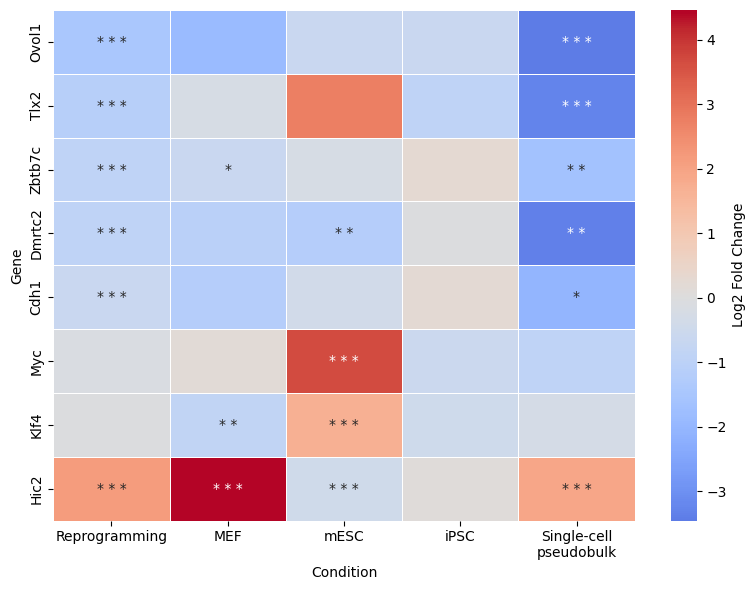

In [64]:
# Plot LFCs

# assign the filtered and sorted dataframe slice to a variable
plot_data = bulk_de.loc[dead_end_tfs + ["Hic2", "Klf4"]].sort_values("Reprogramming LFC")

# separate the log fold change columns and the adjusted p-value columns
lfc_columns = ["Reprogramming LFC", "MEF LFC", "mESC LFC", "iPSC LFC", "Single-cell LFC"]
padj_columns = ["Reprogramming p adjusted", "MEF p adjusted", "mESC p adjusted", "iPSC p adjusted", "Single-cell p adjusted"]

lfc_matrix = plot_data[lfc_columns]
padj_matrix = plot_data[padj_columns]

# clean the column names for the x-axis labels on the final plot
lfc_matrix.columns = ["Reprogramming", "MEF", "mESC", "iPSC", "Single-cell\npseudobulk"]

# convert the adjusted p-values to a float array
padj_array = padj_matrix.to_numpy(dtype=float)
# Replace NaN with 1
numpy.nan_to_num(padj_array, nan=1, copy=False)

# generate an annotation matrix where significant values receive an asterisk
# the condition ignores nan values to prevent runtime warnings
significance_annotations = numpy.full(padj_array.shape, "", dtype=numpy.dtypes.StrDType)
significance_annotations[padj_array < 0.05] += "*"
significance_annotations[padj_array < 0.01] += " *"
significance_annotations[padj_array < 0.001] += " *"
# numpy.where((padj_array < 0.05) & (~numpy.isnan(padj_array)), "*", "")

# initialize the figure canvas
matplotlib.pyplot.figure(figsize=(8, 6))

# plot the heatmap using a divergent colormap centered at zero
seaborn.heatmap(
    data=lfc_matrix,
    annot=significance_annotations,
    fmt="s",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Log2 Fold Change"}
)

# apply axis labels and adjust the layout to prevent clipping
matplotlib.pyplot.xlabel("Condition")
matplotlib.pyplot.ylabel("Gene")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

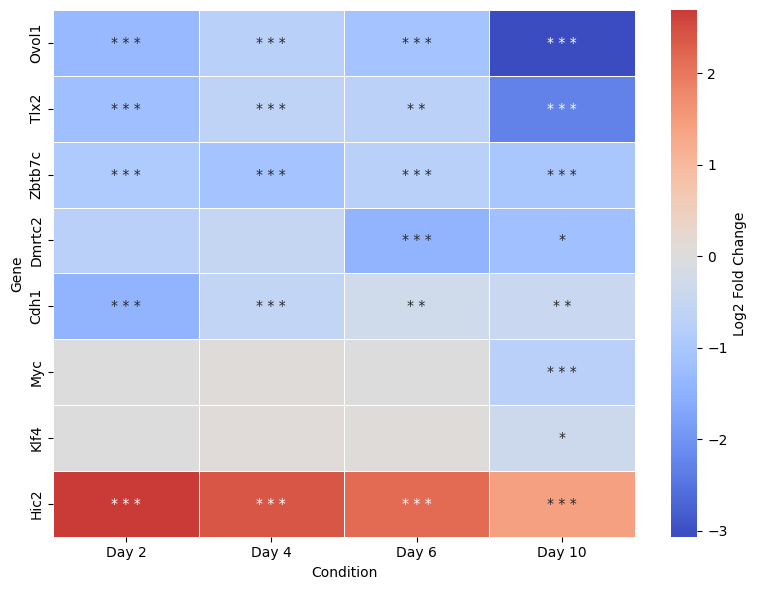

In [65]:
# Compare time points

# assign the filtered and sorted dataframe slice to a variable
plot_data = bulk_de.loc[dead_end_tfs + ["Hic2", "Klf4"]].sort_values("Reprogramming LFC")

# separate the log fold change columns and the adjusted p-value columns
lfc_columns = ["Day 2 LFC", "Day 4 LFC", "Day 6 LFC", "Day 10 LFC"]
padj_columns = ["Day 2 p adjusted", "Day 4 p adjusted", "Day 6 p adjusted", "Day 10 p adjusted"]

lfc_matrix = plot_data[lfc_columns]
padj_matrix = plot_data[padj_columns]

# clean the column names for the x-axis labels on the final plot
lfc_matrix.columns = ["Day 2", "Day 4", "Day 6", "Day 10"]

# convert the adjusted p-values to a float array
padj_array = padj_matrix.to_numpy(dtype=float)
# Replace NaN with 1
numpy.nan_to_num(padj_array, nan=1, copy=False)

# generate an annotation matrix where significant values receive an asterisk
# the condition ignores nan values to prevent runtime warnings
significance_annotations = numpy.full(padj_array.shape, "", dtype=numpy.dtypes.StrDType)
significance_annotations[padj_array < 0.05] += "*"
significance_annotations[padj_array < 0.01] += " *"
significance_annotations[padj_array < 0.001] += " *"
# numpy.where((padj_array < 0.05) & (~numpy.isnan(padj_array)), "*", "")

# initialize the figure canvas
matplotlib.pyplot.figure(figsize=(8, 6))

# plot the heatmap using a divergent colormap centered at zero
seaborn.heatmap(
    data=lfc_matrix,
    annot=significance_annotations,
    fmt="s",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Log2 Fold Change"}
)

# apply axis labels and adjust the layout to prevent clipping
matplotlib.pyplot.xlabel("Condition")
matplotlib.pyplot.ylabel("Gene")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

All except Myc and Tshz1 are significantly downregulated during reprogramming. Most drivers are low in MEFs, stem cells or both so they have high p-values.

Evidence for drivers:
- Barx2: Downregulated in reprogramming, upregulated by Hic2 KO in mESCs but not significantly due to low counts. Could be direct target but there is insufficient evidence.
- Dmrtc2: Downregulated in reprogramming, upregulated by Hic2 KO in mESCs. Probably direct target.
- Hmgb3: Downregulated in reprogramming, upregulated by Hic2 KO in mESCs. Probably direct target.
- Hoxa7: Downregulated in reprogramming, but upregulated in MEFs and downregulated by Hic2 KO in mESCs. Probably not direct target.
- Myc: Downregulated late in reprogramming, but strongly downregulated by Hic2 KO in mESCs. Probably indirect in one of the experiments.
- Ovol1: Downregulated in reprogramming and in the other cells, but too few counts for significance at end points. Could be direct target.
- Phox2a: Downregulated in reprogramming, upregulated by Hic2 KO in mESCs. Probably direct target.
- Tlx2: Downregulated in reprogramming, almost no counts in other cells. Could be direct target, insufficient evidence.
- Tshz1: Upregulated early in reprogramming, downregulated late in reprogramming, upregulated in mESCs. Probably not direct target.
- Zbt7c: Downregulated in reprogramming, downregulated in MEFs and mESCs but not significantly. Could be direct target.

This analysis supports Dmrtc2, Hmgb3 and Phox2a as direct targets, and Barx2, Ovol1, Tlx2 and Zbtb7c could be direct targets.

Hoxa7, Myc and Tshz1 are probably not direct targets based on this analysis.

In [66]:
# Absolute counts for the dead end drivers

bulk_counts[dead_end_tfs]

,Dmrtc2,Myc,Ovol1,Tlx2,Zbtb7c,Cdh1
Day2_BFP_Rep1,58,25073,388,674,1763,2177
Day2_BFP_Rep2,87,35224,669,780,2551,3544
Day2_BFP_Rep3,56,23219,336,654,1525,1973
Day2_Hic2_Rep1,57,41371,266,496,1598,1273
Day2_Hic2_Rep2,45,31895,222,319,1112,1155
Day2_Hic2_Rep3,37,23322,140,257,844,788
Day4_BFP_Rep1,93,30761,1166,939,2928,14617
Day4_BFP_Rep1-2,45,17157,603,549,1711,8136
Day4_BFP_Rep2,164,27347,1056,994,2222,12929
Day4_BFP_Rep3,116,32940,1293,1110,2872,16000


In [67]:
# Differential expression of reprogramming drivers

bulk_de.loc[stem_cell_tfs, reduced_columns]

,Reprogramming LFC,Reprogramming p adjusted,MEF LFC,MEF p adjusted,mESC LFC,mESC p adjusted,iPSC LFC,iPSC p adjusted
Jarid2,0.820343,1.213284e-08,0.209401,0.420568,0.146697,3.744388e-01,-0.079795,0.999695
Klf2,-0.180294,5.962362e-01,-0.868504,0.062581,0.268195,4.393845e-02,-0.408644,0.999695
Rest,0.492894,6.120062e-05,-0.018022,0.926152,0.451593,2.952122e-08,-0.136700,0.999695
Tcf7l1,1.263931,2.178525e-13,0.250631,0.338701,0.472484,6.480603e-03,-0.115792,0.999695
Zfp42,1.344900,6.673669e-18,0.264359,0.852859,1.451497,6.652638e-27,-0.413612,0.999695


In [68]:
# Absolute counts for stem cell drivers

bulk_counts[stem_cell_tfs]

,Jarid2,Klf2,Rest,Tcf7l1,Zfp42
Day2_BFP_Rep1,1538,19,2638,315,89
Day2_BFP_Rep2,2185,47,3534,500,137
Day2_BFP_Rep3,1275,9,2409,279,103
Day2_Hic2_Rep1,2945,35,4665,820,220
Day2_Hic2_Rep2,2325,26,3688,591,228
Day2_Hic2_Rep3,1769,11,2992,451,129
Day4_BFP_Rep1,2205,23,2895,331,224
Day4_BFP_Rep1-2,1269,10,1617,167,136
Day4_BFP_Rep2,1787,51,1976,201,270
Day4_BFP_Rep3,2156,39,2810,334,248


## Save differential expression results

In [69]:
base_name = "RNA Sequencing Data/bulk_differential_expression"

bulk_de.to_csv(f"{base_name}_combined.csv")
metadata_df.to_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv")

reprogramming_de_stats.results_df.to_csv(f"{base_name}_reprogramming.csv")
day_2_de_stats.results_df.to_csv(f"{base_name}_day_2.csv")
day_4_de_stats.results_df.to_csv(f"{base_name}_day_4.csv")
day_6_de_stats.results_df.to_csv(f"{base_name}_day_6.csv")
day_10_de_stats.results_df.to_csv(f"{base_name}_day_10.csv")
esc_de_stats.results_df.to_csv(f"{base_name}_mesc.csv")
mef_de_stats.results_df.to_csv(f"{base_name}_mef.csv")
ipsc_de_stats.results_df.to_csv(f"{base_name}_ipsc.csv")